In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('Dataset/archive(3)/Car_Price_Prediction.csv')
df.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Make          1000 non-null   object 
 1   Model         1000 non-null   object 
 2   Year          1000 non-null   int64  
 3   Engine Size   1000 non-null   float64
 4   Mileage       1000 non-null   int64  
 5   Fuel Type     1000 non-null   object 
 6   Transmission  1000 non-null   object 
 7   Price         1000 non-null   float64
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


# Observation
- Dataset has 1000 rows and 8 columns
- `Price` is the target column
- We have both numerical and categorical columns

In [4]:
df.describe()

,Year,Engine Size,Mileage,Price
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,2010.688000,2.798300,97192.48700,25136.615530
std,6.288577,1.024137,59447.31576,5181.401368
min,2000.000000,1.000000,56.00000,6704.953524
25%,2005.000000,1.900000,44768.75000,21587.878370
50%,2011.000000,2.800000,94411.50000,25189.325247
75%,2016.000000,3.700000,148977.75000,28806.368974
max,2021.000000,4.500000,199867.00000,41780.504635


# Observation
- Car year ranges from 2000 to 2021
- Engine size is between 1.0 and 4.5
- Mileage and price both have a wide spread

In [5]:
df.nunique()

Make               5
Model              5
Year              22
Engine Size       36
Mileage          997
Fuel Type          3
Transmission       2
Price           1000
dtype: int64

# Observation
- `Make`, `Model`, `Fuel Type` and `Transmission` are categorical columns
- These columns have small number of unique values so they can be encoded later if needed

In [6]:
df.isnull().sum()

Make            0
Model           0
Year            0
Engine Size     0
Mileage         0
Fuel Type       0
Transmission    0
Price           0
dtype: int64

# Observation
- There are no missing values in this dataset
- Since the dataset is already clean, we can directly analyze relationships

In [7]:
df['Make'].value_counts()

Make
Ford      225
Audi      212
Honda     198
Toyota    187
BMW       178
Name: count, dtype: int64

In [8]:
df['Fuel Type'].value_counts()

Fuel Type
Diesel      344
Petrol      331
Electric    325
Name: count, dtype: int64

In [9]:
df['Transmission'].value_counts()

Transmission
Manual       511
Automatic    489
Name: count, dtype: int64

# Observation
- Category distribution is fairly balanced
- No category is extremely rare

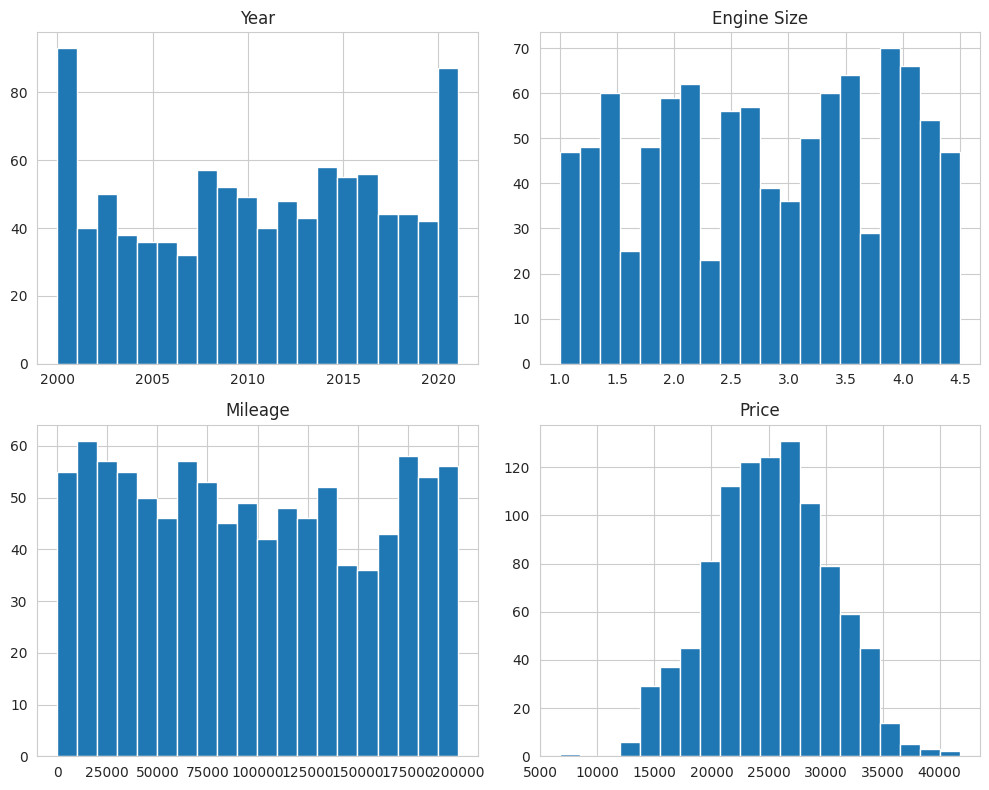

In [10]:
num_cols = ['Year', 'Engine Size', 'Mileage', 'Price']
df[num_cols].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

# Observation
- `Year` looks fairly spread across many years
- `Mileage` has large variation
- `Price` looks reasonably continuous for regression

In [11]:
df[num_cols].corr()

,Year,Engine Size,Mileage,Price
Year,1.000000,-0.012190,0.016376,0.609631
Engine Size,-0.012190,1.000000,-0.014815,0.383951
Mileage,0.016376,-0.014815,1.000000,-0.556560
Price,0.609631,0.383951,-0.556560,1.000000


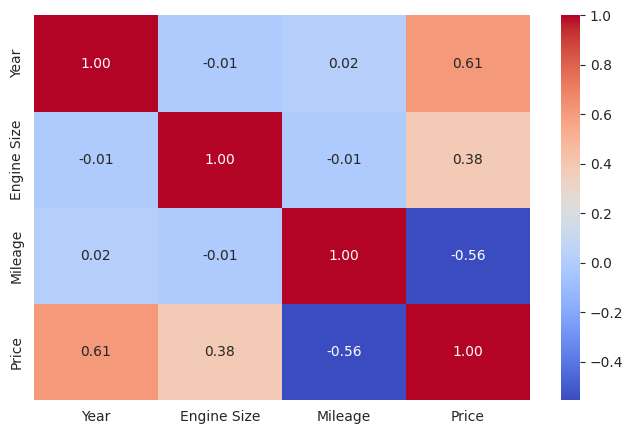

In [12]:
plt.figure(figsize=(8, 5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# Observation
- `Year` has positive correlation with `Price`
- `Mileage` has negative correlation with `Price`
- `Engine Size` also has positive relation with `Price`

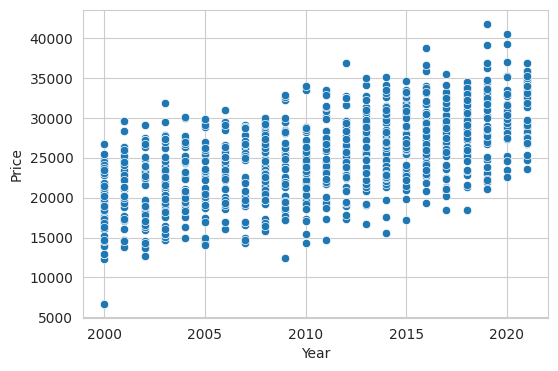

In [13]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Year', y='Price')
plt.show()

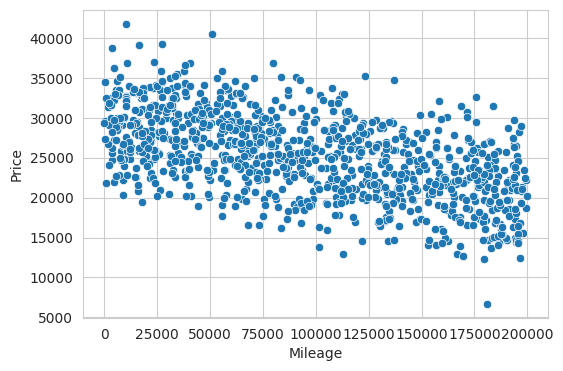

In [14]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Mileage', y='Price')
plt.show()

# Final Observation
- Newer cars tend to have higher price
- Cars with higher mileage tend to have lower price
- For simple linear regression, `Year` or `Mileage` are the best columns to start with

# Feature Engineering
- For multiple regression models, we should prepare categorical columns and create one meaningful feature
- We will create `Car Age` and encode the categorical columns

In [15]:
df_fe = df.copy()
current_year = pd.Timestamp.today().year
df_fe['Car Age'] = current_year - df_fe['Year']
df_fe.head()

,Make,Model,Year,Engine Size,Mileage,Fuel Type,Transmission,Price,Car Age
0,Honda,Model B,2015,3.9,74176,Petrol,Manual,30246.207931,11
1,Ford,Model C,2014,1.7,94799,Electric,Automatic,22785.747684,12
2,BMW,Model B,2006,4.1,98385,Electric,Manual,25760.290347,20
3,Honda,Model B,2015,2.6,88919,Electric,Automatic,25638.003491,11
4,Honda,Model C,2004,3.4,138482,Petrol,Automatic,21021.386657,22


In [16]:
df_fe[['Year', 'Car Age', 'Engine Size', 'Mileage', 'Price']].corr()

,Year,Car Age,Engine Size,Mileage,Price
Year,1.000000,-1.000000,-0.012190,0.016376,0.609631
Car Age,-1.000000,1.000000,0.012190,-0.016376,-0.609631
Engine Size,-0.012190,0.012190,1.000000,-0.014815,0.383951
Mileage,0.016376,-0.016376,-0.014815,1.000000,-0.556560
Price,0.609631,-0.609631,0.383951,-0.556560,1.000000


# Observation
- `Car Age` is easier to understand than raw year
- Since `Car Age` and `Year` represent the same information, we will keep only one of them in the model

In [17]:
df_model = df_fe.drop(columns='Year')
df_model = pd.get_dummies(df_model, columns=['Make', 'Model', 'Fuel Type', 'Transmission'], drop_first=True)
df_model.head()

,Engine Size,Mileage,Price,Car Age,Make_BMW,Make_Ford,Make_Honda,Make_Toyota,Model_Model B,Model_Model C,Model_Model D,Model_Model E,Fuel Type_Electric,Fuel Type_Petrol,Transmission_Manual
0,3.9,74176,30246.207931,11,False,False,True,False,True,False,False,False,False,True,True
1,1.7,94799,22785.747684,12,False,True,False,False,False,True,False,False,True,False,False
2,4.1,98385,25760.290347,20,True,False,False,False,True,False,False,False,True,False,True
3,2.6,88919,25638.003491,11,False,False,True,False,True,False,False,False,True,False,False
4,3.4,138482,21021.386657,22,False,False,True,False,False,True,False,False,False,True,False


# Observation
- Categorical columns are converted into numeric columns
- Now the dataset is ready for regression models like Linear, Ridge, Lasso and Random Forest Regressor

# Feature Selection
- We will first check the important numeric features
- Then we will rank all engineered features using `SelectKBest`

In [18]:
df_fe[['Car Age', 'Engine Size', 'Mileage', 'Price']].corr()['Price'].sort_values(ascending=False)

Price          1.000000
Engine Size    0.383951
Mileage       -0.556560
Car Age       -0.609631
Name: Price, dtype: float64

In [19]:
from sklearn.feature_selection import SelectKBest, f_regression

In [20]:
X = df_model.drop(columns='Price')
y = df_model['Price']

selector = SelectKBest(score_func=f_regression, k=10)
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

feature_scores.head(10)

,Feature,Score
2,Car Age,590.286363
1,Mileage,447.871416
0,Engine Size,172.562892
5,Make_Honda,2.946907
13,Transmission_Manual,0.653566
6,Make_Toyota,0.429489
4,Make_Ford,0.401904
9,Model_Model D,0.173002
8,Model_Model C,0.125588
11,Fuel Type_Electric,0.121599


# Final Conclusion
- For simple regression, `Year`, `Car Age` or `Mileage` are the best starting features
- For multiple regression, use the engineered dataset `df_model`
- `Car Age`, `Mileage`, `Engine Size` and encoded categorical columns should be used for model training
- We should not keep both `Year` and `Car Age` together because they carry the same information